# Project Setup & Data Loading

This notebook initializes the project environment and loads the dataset for the disease prediction system. The goal is to understand the dataset structure before performing any preprocessing or modeling.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [4]:
# Load dataset
file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

df = pd.read_csv(f'{file_path}/heart_disease_uci.csv')
df.shape

(920, 16)

ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


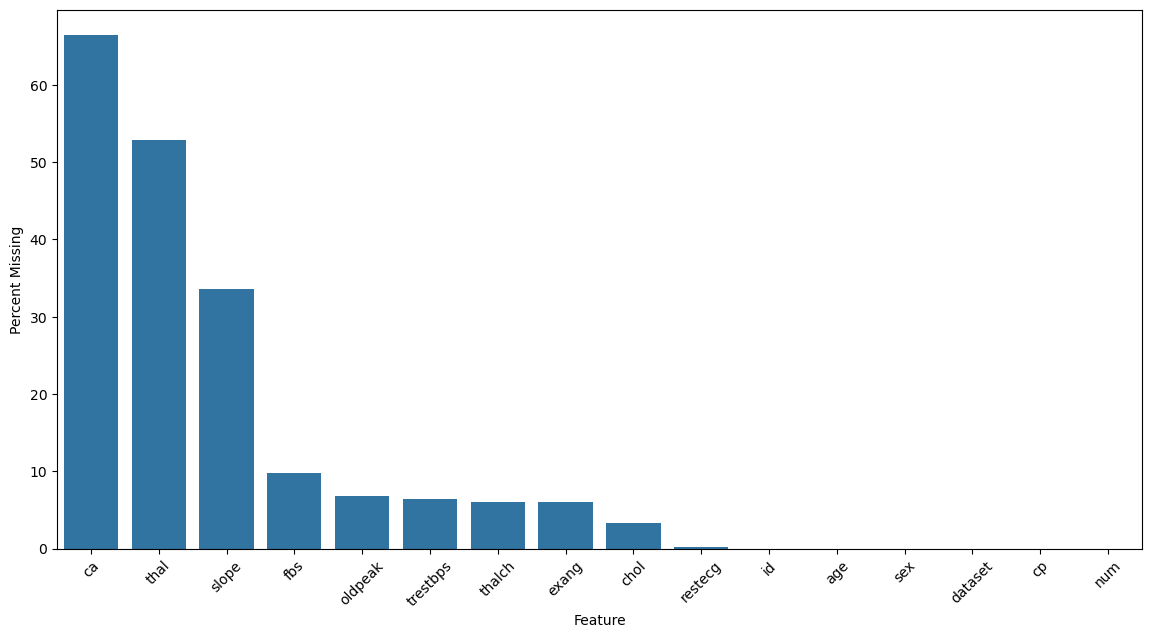

In [5]:
percent_missing = df.isnull().sum() / len(df) * 100
percent_missing = pd.DataFrame(percent_missing)
percent_missing.reset_index(inplace = True)
percent_missing.columns = ["Feature","Percent Missing"]

# Sorting the data first, then pass the sorted Feature index to order
ordered_features = percent_missing.sort_values('Percent Missing', ascending=False)['Feature']
plt.figure(figsize = (14,7))
plt.xticks(rotation = 45)
sns.barplot(x = "Feature", y = "Percent Missing", data = percent_missing, order=ordered_features)
df.shape

print(df['ca'].value_counts(dropna=False))
print(df['thal'].value_counts(dropna=False))


## Initial Observations
- `ca` and `thal` have high missing values (~66% and ~53% respectively), but are clinically significant features. Rather than dropping them, missing indicators will be added and KNN imputation will be applied in the preprocessing stage.
- `slope` contains ~30% missing values and will also be handled via imputation.
- Remaining features have low or no missingness and are suitable for standard preprocessing.
We will try and fix the columns that contain fewer missing values like fbs, oldpeak, trestbps, thalch, exang, chol, restecg.

In [4]:
# Saving raw unmodified data to processed folder as a starting checkpoint for notebook 02.
df.to_csv(f'{file_path}/data/processed/heart_disease_raw.csv', index=False)
print("Raw data saved. Shape:", df.shape)

Raw data saved. Shape: (920, 16)
